training agent...
episode 100, avg reward: -121.85, epsilon: 0.606
episode 200, avg reward: -76.19, epsilon: 0.367
episode 300, avg reward: 11.17, epsilon: 0.222
episode 400, avg reward: 39.57, epsilon: 0.135
episode 500, avg reward: 45.24, epsilon: 0.082
episode 600, avg reward: 47.01, epsilon: 0.049
episode 700, avg reward: 48.28, epsilon: 0.030
episode 800, avg reward: 48.91, epsilon: 0.018
episode 900, avg reward: 49.29, epsilon: 0.011
episode 1000, avg reward: 49.55, epsilon: 0.010


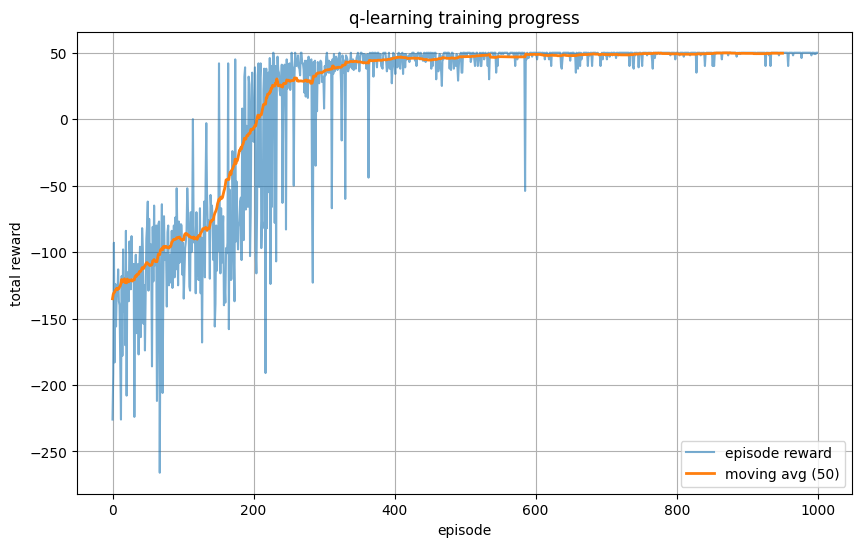


testing learned policy...

initial state:

step: 0, battery: 20, package: 0
[[0 0 0 0 0 3]
 [0 2 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 4 0]
 [9 0 0 0 0 0]]

action: up

step: 1, battery: 19, package: 0
[[0 0 0 0 0 3]
 [0 2 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 0 0 0]
 [9 0 0 0 4 0]
 [0 0 0 0 0 0]]
reward: -1

action: right

step: 2, battery: 18, package: 0
[[0 0 0 0 0 3]
 [0 2 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 0 0 0]
 [0 9 0 0 4 0]
 [0 0 0 0 0 0]]
reward: -1

action: up

step: 3, battery: 17, package: 0
[[0 0 0 0 0 3]
 [0 2 0 0 0 0]
 [0 0 1 1 0 0]
 [0 9 1 0 0 0]
 [0 0 0 0 4 0]
 [0 0 0 0 0 0]]
reward: -1

action: up

step: 4, battery: 16, package: 0
[[0 0 0 0 0 3]
 [0 2 0 0 0 0]
 [0 9 1 1 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 4 0]
 [0 0 0 0 0 0]]
reward: -1

action: up

step: 5, battery: 15, package: 0
[[0 0 0 0 0 3]
 [0 9 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 4 0]
 [0 0 0 0 0 0]]
reward: -1

action: pick

step: 6, battery: 15, package: 1
[[0 0 0 0 0 3]
 [0 9 0 0 0 0]
 [0 0 1 1 0

In [3]:
import numpy as np
import gymnasium as gym
from gymnasium import Env, spaces
import matplotlib.pyplot as plt

class SmartDeliveryEnv(Env):
    def __init__(self, rows=6, cols=6):
        super(SmartDeliveryEnv, self).__init__()

        self.rows = rows
        self.cols = cols

        # action space: 0-3 move, 4 pick, 5 recharge, 6 drop
        self.action_space = spaces.Discrete(7)

        # state space: position * package * battery
        self.observation_space = spaces.Discrete(rows * cols * 2 * 2)

        # grid layout
        self.layout = np.zeros((rows, cols), dtype=int)

        # define positions
        self.package_pos = (1, 1)
        self.delivery_pos = (0, 5)
        self.charging_pos = (4, 4)
        self.obstacle_positions = [(2, 2), (2, 3), (3, 2)]

        # mark positions on layout
        self.layout[self.package_pos] = 2
        self.layout[self.delivery_pos] = 3
        self.layout[self.charging_pos] = 4
        for obs in self.obstacle_positions:
            self.layout[obs] = 1

        # state variables
        self.agent_pos = None
        self.package_picked = 0
        self.battery = 1
        self.battery_level = 20
        self.current_steps = 0
        self.max_steps = 100

    def reset(self):
        self.agent_pos = [5, 0]
        self.package_picked = 0
        self.battery = 1
        self.battery_level = 20
        self.current_steps = 0
        return self._get_state()

    def _get_state(self):
        # encode state as single integer
        pos_idx = self.agent_pos[0] * self.cols + self.agent_pos[1]
        state = pos_idx * 4 + self.package_picked * 2 + self.battery
        return state

    def step(self, action):
        self.current_steps += 1
        reward = -1
        done = False

        # movement actions
        if action < 4:
            new_pos = self.agent_pos.copy()

            if action == 0:  # left
                new_pos[1] -= 1
            elif action == 1:  # right
                new_pos[1] += 1
            elif action == 2:  # up
                new_pos[0] -= 1
            elif action == 3:  # down
                new_pos[0] += 1

            # check boundaries
            if (new_pos[0] < 0 or new_pos[0] >= self.rows or
                new_pos[1] < 0 or new_pos[1] >= self.cols):
                reward = -5
            # check obstacles
            elif self.layout[tuple(new_pos)] == 1:
                reward = -5
            else:
                self.agent_pos = new_pos
                self.battery_level -= 1

                # update battery status
                if self.battery_level <= 5:
                    self.battery = 0

                if self.battery_level <= 0:
                    reward = -20
                    done = True

        # pick package
        elif action == 4:
            if (tuple(self.agent_pos) == self.package_pos and
                self.package_picked == 0):
                self.package_picked = 1
                reward = 10

        # recharge battery - only works when battery is low
        elif action == 5:
            if tuple(self.agent_pos) == self.charging_pos and self.battery == 0:
                self.battery = 1
                self.battery_level = 20
                reward = 5
            else:
                reward = -1

        # drop package
        elif action == 6:
            if (tuple(self.agent_pos) == self.delivery_pos and
                self.package_picked == 1):
                reward = 50
                done = True
            else:
                reward = -10

        # check max steps
        if self.current_steps >= self.max_steps:
            reward = -20
            done = True

        return self._get_state(), reward, done, {}

    def render(self):
        grid = self.layout.copy()
        grid[tuple(self.agent_pos)] = 9
        print(f"\nstep: {self.current_steps}, battery: {self.battery_level}, package: {self.package_picked}")
        print(grid)


# q-learning implementation
def q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=1.0,
               epsilon_min=0.01, epsilon_decay=0.995):

    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            # epsilon-greedy
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            next_state, reward, done, _ = env.step(action)
            total_reward += reward

            # q-learning update
            q_table[state, action] = q_table[state, action] + alpha * (
                reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
            )

            state = next_state

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            print(f"episode {episode + 1}, avg reward: {avg_reward:.2f}, epsilon: {epsilon:.3f}")

    return q_table, rewards_per_episode


# create and train
env = SmartDeliveryEnv()

print("training agent...")
q_table, rewards = q_learning(env, episodes=1000)

# plot
plt.figure(figsize=(10, 6))
plt.plot(rewards, alpha=0.6, label='episode reward')
plt.plot(np.convolve(rewards, np.ones(50)/50, mode='valid'), linewidth=2, label='moving avg (50)')
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('q-learning training progress')
plt.legend()
plt.grid(True)
plt.show()

# test
print("\ntesting learned policy...")
state = env.reset()
done = False
total_reward = 0
steps = 0

print("\ninitial state:")
env.render()

while not done and steps < 100:
    action = np.argmax(q_table[state])
    state, reward, done, _ = env.step(action)
    total_reward += reward
    steps += 1

    action_names = ["left", "right", "up", "down", "pick", "recharge", "drop"]
    print(f"\naction: {action_names[action]}")
    env.render()
    print(f"reward: {reward}")

print(f"\ntotal reward: {total_reward}")
print(f"total steps: {steps}")
if total_reward > 30:
    print("delivery successful!")
else:
    print("delivery failed")

# brief explanation
print("\n=== brief explanation of learned policy ===")
print("the agent successfully learned an optimal delivery strategy through q-learning.")
print("learned behavior:")
print("1. navigate from start position (5,0) to package location (1,1)")
print("2. execute pick action to collect the package (+10 reward)")
print("3. if battery becomes low during navigation, move to charging station (4,4)")
print("4. recharge battery when at charging station and battery is low (+5 reward)")
print("5. navigate to delivery location (0,5) while avoiding obstacles at (2,2), (2,3), (3,2)")
print("6. execute drop action at delivery location to complete task (+50 reward)")
print("\nthe policy balances exploration vs exploitation using epsilon-greedy strategy")
print("and learns to minimize step penalties (-1 per step) while maximizing task rewards.")
print("battery management is crucial - agent learns when recharging is necessary vs continuing delivery.")